In [1]:
! pip install scikit-fuzzy


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

#### Fuzzy variables

In [3]:
res = 100
price_change = ctrl.Antecedent(np.linspace(-1, 1, res), "Price Change") #array of price changes
action = ctrl.Antecedent(np.arange(0, 3, 1), "Action") #0: Sell, 1: Hold, 2: Buy
time_cycle = ctrl.Antecedent(np.linspace(1, 24*60, res), "time_cycle") #array of price changes

reward = ctrl.Consequent(np.linspace(-10, 10, res), 'Reward')

#### Membership functions

c:\Andrey\Kakua_Projets\Trading\Bot_RL_v1\venv\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


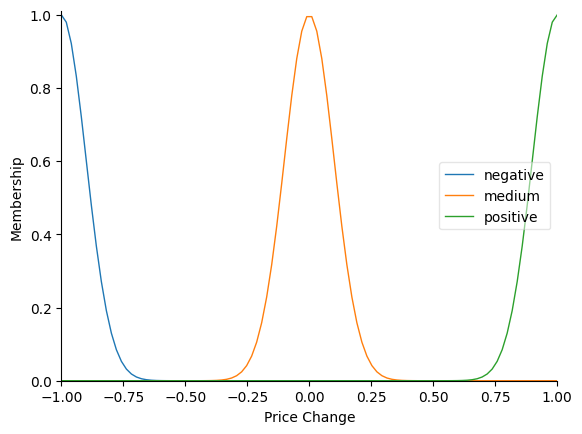

In [4]:
price_change["negative"] = fuzz.gaussmf(price_change.universe, -1, 0.1)
price_change["medium"] = fuzz.gaussmf(price_change.universe, 0, 0.1)
price_change["positive"] = fuzz.gaussmf(price_change.universe, 1, 0.1)

price_change.view()

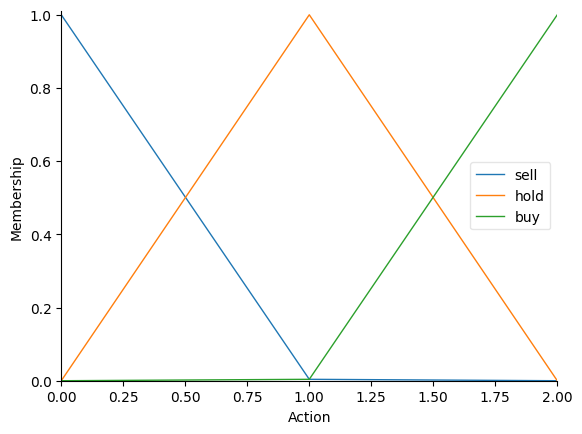

In [5]:
action["sell"] = fuzz.gaussmf(action.universe, 0, 0.3)
action["hold"] = fuzz.gaussmf(action.universe, 1, 0.1)
action["buy"] = fuzz.gaussmf(action.universe, 2, 0.3)

action.view()

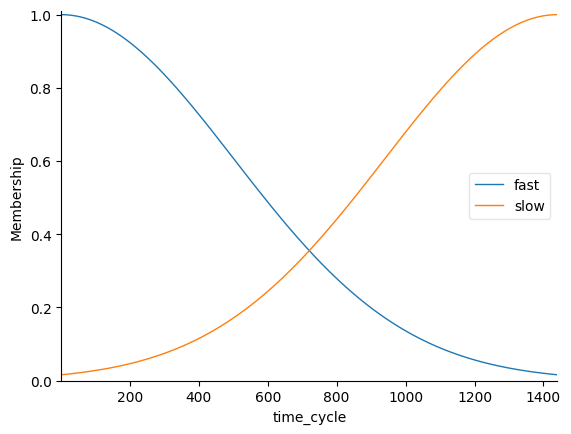

In [6]:
time_cycle["fast"] = fuzz.gaussmf(time_cycle.universe, 1, 500)
#time_cycle["medium"] = fuzz.gaussmf(time_cycle.universe, 700, 200)
time_cycle["slow"] = fuzz.gaussmf(time_cycle.universe, 24*60, 500)


time_cycle.view()

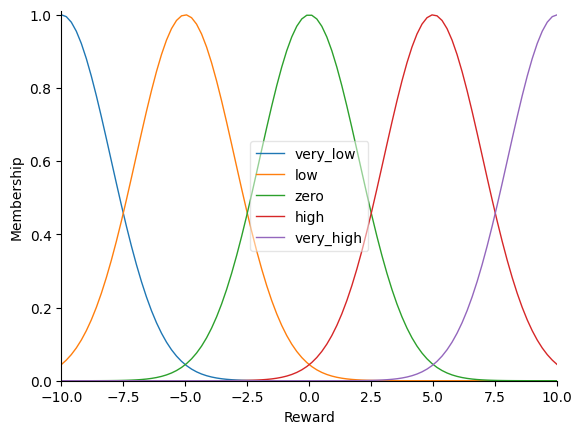

In [7]:
reward["very_low"] = fuzz.gaussmf(reward.universe, -10, 2)
reward["low"] = fuzz.gaussmf(reward.universe, -5, 2)
reward["zero"] = fuzz.gaussmf(reward.universe, 0, 2)
reward["high"] = fuzz.gaussmf(reward.universe, 5, 2)
reward["very_high"] = fuzz.gaussmf(reward.universe, 10, 2)

reward.view()

#### Inference rules

In [8]:
# price_change
# action
# time_cycle

rule1 = ctrl.Rule(price_change["negative"] & time_cycle["fast"] & action['sell'], reward['low'])
rule2 = ctrl.Rule(price_change["negative"] & time_cycle["slow"] & action['sell'], reward['very_low'])
rule3 = ctrl.Rule(price_change["positive"] & time_cycle["fast"] & action['buy'], reward['high'])
rule4 = ctrl.Rule(price_change["positive"] & time_cycle["slow"] & action['buy'], reward['very_high'])
rule5 = ctrl.Rule(price_change["negative"] & time_cycle["fast"] & action['buy'], reward['very_low'])
rule6 = ctrl.Rule(price_change["negative"] & time_cycle["slow"] & action['buy'], reward['very_low'])
#rule7 = ctrl.Rule(price_change["medium"] & (action['sell'] | action['buy']), reward['low']) # low
rule7 = ctrl.Rule(price_change["medium"] & action['hold'], reward['zero']) # high


#### Fuzzy inference

In [9]:
system = ctrl.ControlSystem(rules=[rule1, rule2, rule3, rule4, rule5, rule6, rule7])
sim = ctrl.ControlSystemSimulation(system)

In [10]:
# generate inference surface
price_change_space = np.linspace(-1, 1, res)
action_space = np.arange(0, 3, 1)
time_cycle_space = np.linspace(1, 24*60, res)
x, y = np.meshgrid(price_change_space, time_cycle_space)
z1 = np.zeros_like(x)
z2 = np.zeros_like(x)
z3 = np.zeros_like(x)


for i in range(res):
    for j in range(res):
        for k in range(len(action_space)):
        
            sim.input['Price Change'] = x[i, j]
            sim.input['Action'] = action_space[k]
            sim.input['time_cycle'] = y[i, j]

            sim.compute()

            if k == 0:
                z1[i, j] = sim.output['Reward']
            elif k == 1:
                z2[i, j] = sim.output['Reward']
            elif k == 2:
                z3[i, j] = sim.output['Reward']

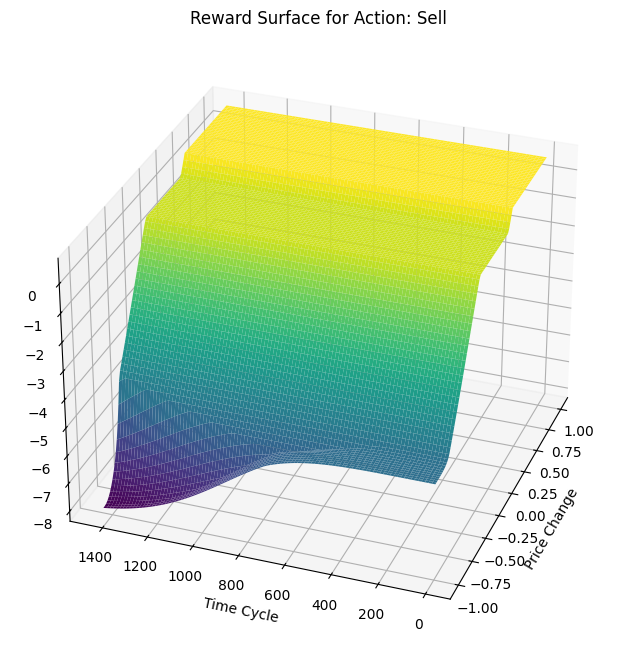

In [11]:
# Plot the result in pretty 3D with alpha blending
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(x, y, z1, rstride=1, cstride=1, cmap='viridis',
                       linewidth=0.4, antialiased=True)

ax.set_xlabel("Price Change")
ax.set_ylabel("Time Cycle")
ax.set_title("Reward Surface for Action: Sell")

ax.view_init(30, 200)

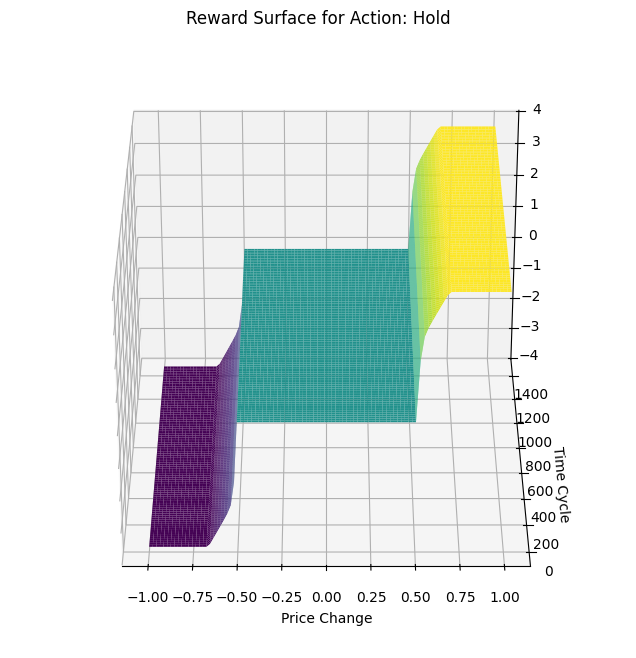

In [12]:
# Plot the result in pretty 3D with alpha blending
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(x, y, z2, rstride=1, cstride=1, cmap='viridis',
                       linewidth=0.4, antialiased=True)

ax.set_xlabel("Price Change")
ax.set_ylabel("Time Cycle")
ax.set_title("Reward Surface for Action: Hold")

ax.view_init(30, 270)

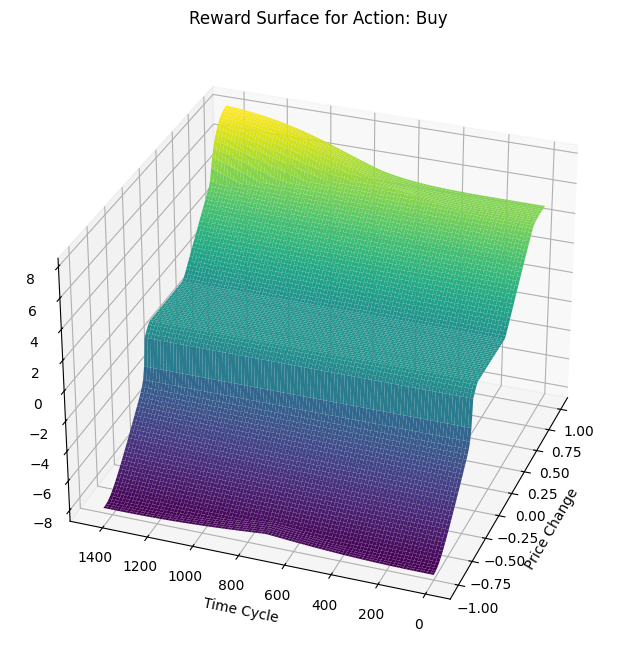

: 

In [ ]:
# Plot the result in pretty 3D with alpha blending
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(x, y, z3, rstride=1, cstride=1, cmap='viridis',
                       linewidth=0.4, antialiased=True)

ax.set_xlabel("Price Change")
ax.set_ylabel("Time Cycle")
ax.set_title("Reward Surface for Action: Buy")

ax.view_init(30, 200)